In [2]:

from dotenv import load_dotenv
from typing import Annotated

from pydantic_core.core_schema import none_schema
from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

load_dotenv()

True

In [3]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")

class state(TypedDict):
    messages: Annotated[list, add_messages]


def chatbot(state:state) -> state:
    return {"messages": [llm.invoke(state["messages"])]}

In [4]:


builder = StateGraph(state)

builder.add_node("Chatbot", chatbot)


builder.add_edge(START , "Chatbot")
builder.add_edge( "Chatbot", END)


graph = builder.compile()

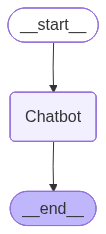

In [5]:
from IPython.display import Image , display



display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
msg = {"role":"user","content":"hello how are you?"}
response = graph.invoke({"messages": [msg]})

# llm = init_chat_model("groq:llama-3.3-70b-versatile")
# response = llm.invoke("hello")
response["messages"]

[HumanMessage(content='hello how are you?', additional_kwargs={}, response_metadata={}, id='a96a7d5e-ff4b-41cf-b207-5cd5ebc8fa74'),
 AIMessage(content="Hello, I'm doing well, thanks for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 40, 'total_tokens': 97, 'completion_time': 0.131255053, 'completion_tokens_details': None, 'prompt_time': 0.001667446, 'prompt_tokens_details': None, 'queue_time': 0.05501444, 'total_time': 0.132922499}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f09a8-27bb-7bb3-8ca8-4810ab318b8f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens

In [7]:
state = None
while True:
    msg = input("enter the question: ")
    if msg.lower() in {"quit", "exit"}:
        break
    if state is None:
        state: state = {
            "messages": [{"role":"user","content":msg}]
        }
    else:
        state["messages"].append({"role":"user","content":msg})


    state = graph.invoke(state)
    print("bot:",state["messages"][-1].content)



bot: It's nice to meet you. Is there something I can help you with or would you like to chat?
bot: होय, मी मराठीत बोलू शकतो. तुम्हाला काय विचारायचं आहे की काय बोलायचं आहे? (Hoay, me marathit bolu shakto. Tumhala kay vicharaycha ahe ki kay bolaycha ahe?) 

मी तुमच्या सोबत मराठीत बोलण्यास तयार आहे. (Me tumchyasobat marathit bolanyas tayár ahe.)
bot: माफ करा (Maaf kara), मी एक टेक्स्ट-आधारित AI आहे (Me ek text-aadharit AI ahe), म्हणून मी तुमच्याशी फक्त टेक्स्टद्वारे संवाद साधू शकतो (Mhanun me tumchyashi fakta textdwaare sanvaad saadhu shakto). मी तुमच्या समोर बोलत नाही कारण माझी कोणतीही आवाज नाही (Me tumchyaa samor bolat nahin kaaran mazi kaintihi aavaj nahi).

पण मी तुमच्या प्रश्नांची उत्तरे देण्यासाठी आणि तुमच्याशी मराठीत बोलण्यासाठी तयार आहे (Pann me tumchyaa prashnaanchi uttare denyasathi aaani tumchyashi marathit bolanyasathi tayár ahe).
bot: तुम्ही माझ्या वापरासाठी व्हॉइस एजेंट तयार करू शकता (Tumhi majhyaa vaaparaasathi voice agent tayyar karu shakta), पण त्यासाठी काही तांत्रिक गोष्

KeyboardInterrupt: Interrupted by user